In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow.keras import layers, models
import pickle

In [7]:
df = pd.read_csv("../data/churn_data.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,1,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,29.85,0
1,5575-GNVDE,0,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1889.50,0
2,3668-QPYBK,0,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,108.15,1
3,7795-CFOCW,0,0,0,0,45,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1840.75,0
4,9237-HQITU,1,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,151.65,1


In [9]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   int64  
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   int64  
 4   Dependents        7043 non-null   int64  
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   int64  
 7   MultipleLines     7043 non-null   int64  
 8   InternetService   7043 non-null   int64  
 9   OnlineSecurity    7043 non-null   int64  
 10  OnlineBackup      7043 non-null   int64  
 11  DeviceProtection  7043 non-null   int64  
 12  TechSupport       7043 non-null   int64  
 13  StreamingTV       7043 non-null   int64  
 14  StreamingMovies   7043 non-null   int64  
 15  Contract          7043 non-null   int64  
 16  PaperlessBilling  7043 non-null   int64  


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [11]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())


=== Target Variable Distribution ===


Churn
0    5174
1    1869
Name: count, dtype: int64

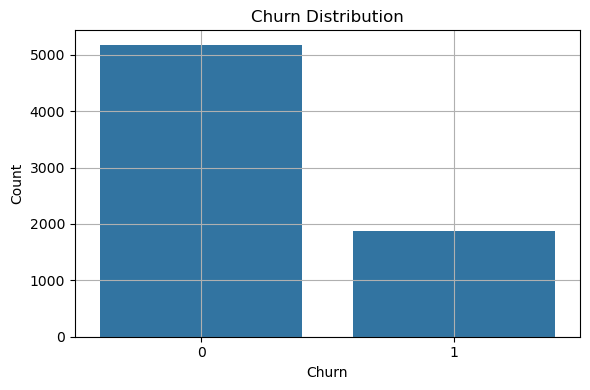


 Numeric Column Outlier Summary:
                  Outlier Count
gender                        0
SeniorCitizen              1142
Partner                       0
Dependents                    0
tenure                        0
PhoneService                682
MultipleLines                 0
InternetService               0
OnlineSecurity                0
OnlineBackup                  0
DeviceProtection              0
TechSupport                   0
StreamingTV                   0
StreamingMovies               0
Contract                      0
PaperlessBilling              0
PaymentMethod                 0
MonthlyCharges                0
TotalCharges                  0
Churn                         0


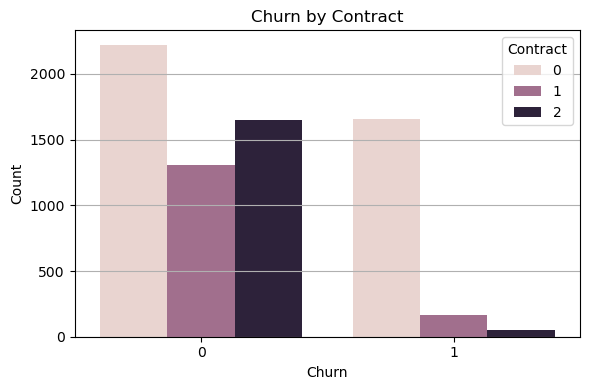

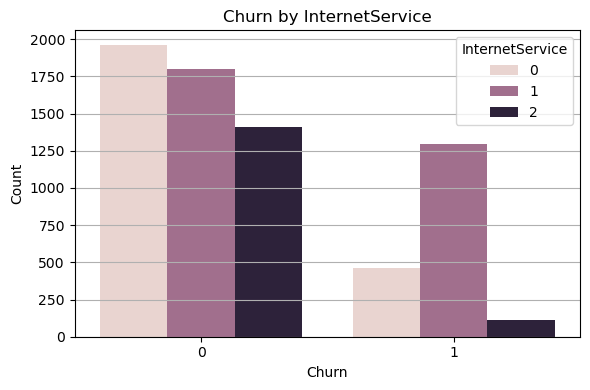

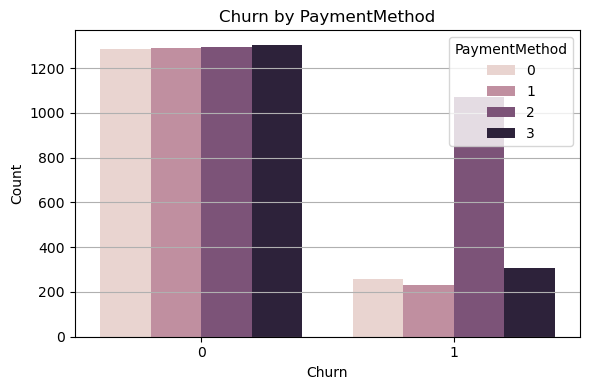

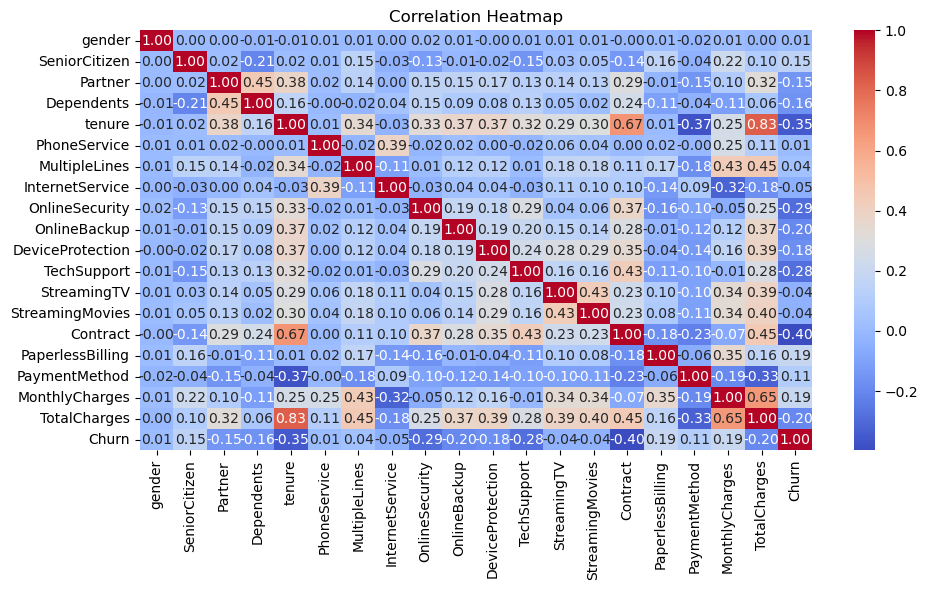


 Hidden Patterns: Contract vs Churn


,Contract,Churn,Count
0,0,0,2220
1,0,1,1655
2,1,0,1307
3,1,1,166
4,2,0,1647
5,2,1,48


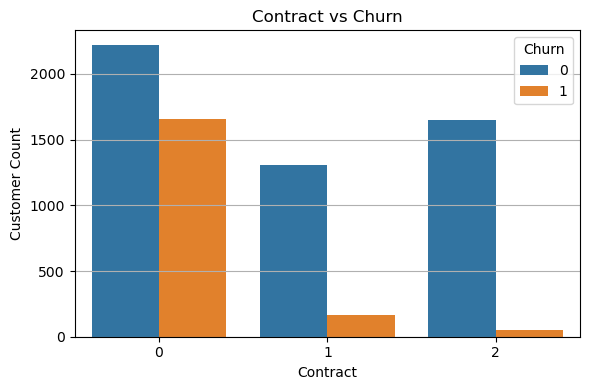


Telco Churn EDA Completed! Plots saved in reports/eda_figures/telco_churn/


In [20]:
# 3A. EDA for Telco Customer Churn (Structured Data)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

logging.info("Starting EDA for Telco Customer Churn data.")

# Create folder for saving Telco EDA figures
Outputs = r"C:\Users\91990\Projects\Customer_Churn_Prediction\Outputs"
os.makedirs(Outputs, exist_ok=True)

logging.basicConfig(filename=os.path.join(Outputs, "eda_log.txt"), level=logging.INFO)

# 1. Target Variable Distribution
print("\n=== Target Variable Distribution ===")
display(df['Churn'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn')
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(Outputs, "target_distribution.png"))
plt.show()
plt.close()
logging.info("Target variable distribution plot saved")

# 2. Numeric Column Stats & Outliers
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
outlier_summary = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    outlier_summary[col] = len(outliers)

outlier_df = pd.DataFrame.from_dict(outlier_summary, orient='index', columns=['Outlier Count'])
print("\n Numeric Column Outlier Summary:")
print(outlier_df)

# 3. Categorical Column Patterns
categorical_cols = df.select_dtypes(include=['object']).columns.drop('customerID')

for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(y=col, data=telco_df, order=df[col].value_counts().index)
    plt.title(f"{col} Value Counts")
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.grid(axis='x')
    plt.tight_layout()
    plt.savefig(os.path.join(Outputs, f"{col}_value_counts.png"))
    plt.show()
    plt.close()
logging.info("Categorical plots saved")

# 4. Key Bivariate Analysis: Churn vs Select Important Categorical Features 
key_cols = ['Contract', 'InternetService', 'PaymentMethod'] 
for col in key_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x='Churn', hue=col, data=df)
    plt.title(f"Churn by {col}")
    plt.xlabel('Churn')
    plt.ylabel('Count')
    plt.grid(axis='y')
    plt.tight_layout()
    plt.savefig(os.path.join(Outputs, f"churn_by_{col}.png"))
    plt.show()
    plt.close()
logging.info("Bivariate analysis plots saved")

# 5. Correlation  Heatmap & Multivariate Analysis
plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig(os.path.join(Outputs, "correlation_heatmap.png"))
plt.show()
plt.close()
logging.info("Correlation heatmap saved")

# 6. Hidden Patterns / Grouped Analysis
grouped = df.groupby(['Contract','Churn'])['customerID'].count().reset_index()
grouped.rename(columns={'customerID':'Count'}, inplace=True)
print("\n Hidden Patterns: Contract vs Churn")
display(grouped)

plt.figure(figsize=(6,4))
sns.barplot(data=grouped, x='Contract', y='Count', hue='Churn')
plt.title("Contract vs Churn")
plt.xlabel('Contract')
plt.ylabel('Customer Count')
plt.grid(axis='y')
plt.tight_layout()
plt.savefig(os.path.join(Outputs, "contract_vs_churn.png"))
plt.show()
plt.close()
logging.info("Grouped analysis plot saved")

logging.info("Telco Churn EDA Completed")

In [21]:
# Drop unnecessary columns
df.drop(['customerID'], axis=1, inplace=True)

# Encode categorical variables
cat_cols = df.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Split features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [25]:
pickle.dump(scaler, open("C:/Users/91990/Projects/Customer_Churn_Prediction/Models/scaler.pkl", "wb"))
pickle.dump(le, open("C:/Users/91990/Projects/Customer_Churn_Prediction/Models/encoder.pkl", "wb"))

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [27]:
model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, validation_split=0.2, epochs=50, batch_size=32, verbose=1)

C:\Users\91990\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7291 - loss: 0.5261 - val_accuracy: 0.7924 - val_loss: 0.4346
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7781 - loss: 0.4698 - val_accuracy: 0.7933 - val_loss: 0.4228
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7781 - loss: 0.4586 - val_accuracy: 0.8004 - val_loss: 0.4196
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7839 - loss: 0.4476 - val_accuracy: 0.7977 - val_loss: 0.4157
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7894 - loss: 0.4400 - val_accuracy: 0.8030 - val_loss: 0.4125
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7905 - loss: 0.4374 - val_accuracy: 0.7924 - val_loss: 0.4135
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7930 - loss: 0.4375 - val_accuracy: 0.7986 - val_loss: 0.4125
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7897 - loss: 0.4372 - val_accuracy: 0.

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
              precision    recall  f1-score   support

           0       0.84      0.93      0.88      1036
           1       0.71      0.50      0.59       373

    accuracy                           0.81      1409
   macro avg       0.78      0.71      0.73      1409
weighted avg       0.80      0.81      0.80      1409



<Axes: >

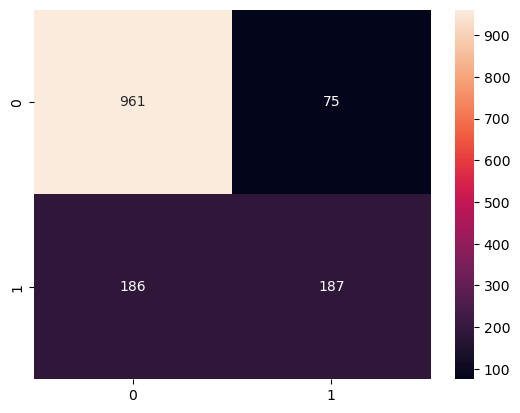

In [28]:
y_pred = (model.predict(X_test) > 0.5).astype("int32")
print(classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')

In [30]:
model.save("C:/Users/91990/Projects/Customer_Churn_Prediction/Models/churn_model.h5")

In [31]:
feature_names = X.columns.tolist()
import joblib
joblib.dump(feature_names, "C:/Users/91990/Projects/Customer_Churn_Prediction/Models/feature_names.pkl")

['C:/Users/91990/Projects/Customer_Churn_Prediction/Models/feature_names.pkl']